In [7]:
import cv2
import os
import csv
import random
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


# ==========================================
# 1 - مسار الصور
# ==========================================

dataset_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\dogs-vs-cats\train\train"


# ==========================================
# 2 - الحصول على جميع الصور
# ==========================================

all_images = []

for image_name in os.listdir(dataset_path):

    if image_name.lower().endswith(
        (".jpg", ".jpeg", ".png")
    ):

        if image_name.lower().startswith("cat") or \
           image_name.lower().startswith("dog"):

            all_images.append(image_name)


print("عدد الصور الموجودة:", len(all_images))


# ==========================================
# 3 - اختيار 2000 صورة عشوائية
# ==========================================

random.seed(42)

number_of_images = min(2000, len(all_images))

selected_images = random.sample(
    all_images,
    number_of_images
)

print("عدد الصور المختارة:", len(selected_images))


# ==========================================
# 4 - تجهيز الصور
# ==========================================

X = []
y = []
names = []

image_size = (64, 64)


for image_name in selected_images:

    image_path = os.path.join(
        dataset_path,
        image_name
    )

    # قراءة الصورة
    image = cv2.imread(image_path)

    if image is None:
        continue

    # تغيير حجم الصورة
    image = cv2.resize(
        image,
        image_size
    )

    # تحويل إلى Gray
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    # تحويل الصورة إلى أرقام
    features = gray.flatten()

    X.append(features)

    # ======================================
    # Cat = 0
    # Dog = 1
    # ======================================

    if image_name.lower().startswith("cat"):

        y.append(0)

    else:

        y.append(1)

    names.append(image_name)


# ==========================================
# 5 - تحويل إلى NumPy
# ==========================================

X = np.array(X)
y = np.array(y)

print("الصور الجاهزة:", len(X))
print("عدد القطط:", np.sum(y == 0))
print("عدد الكلاب:", np.sum(y == 1))


# ==========================================
# 6 - تقسيم البيانات
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


print("صور التدريب:", len(X_train))
print("صور الاختبار:", len(X_test))


# ==========================================
# 7 - تدريب النموذج
# ==========================================

print("\nجاري تدريب النموذج...")

model = SVC(
    kernel="linear"
)

model.fit(
    X_train,
    y_train
)

print("تم التدريب بنجاح")


# ==========================================
# 8 - اختبار النموذج
# ==========================================

y_pred = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:")
print(accuracy)


# ==========================================
# 9 - حفظ نتائج الاختبار في CSV
# ==========================================

csv_file = "cat_dog_results.csv"

with open(
    csv_file,
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.writer(file)

    writer.writerow([
        "Image",
        "Prediction",
        "Animal"
    ])

    for i in range(len(y_test)):

        if y_pred[i] == 0:

            animal = "Cat"

        else:

            animal = "Dog"

        writer.writerow([
            i + 1,
            y_pred[i],
            animal
        ])


print("\nتم إنشاء ملف CSV:")
print(csv_file)

عدد الصور الموجودة: 25000
عدد الصور المختارة: 2000
الصور الجاهزة: 2000
عدد القطط: 982
عدد الكلاب: 1018
صور التدريب: 1600
صور الاختبار: 400

جاري تدريب النموذج...
تم التدريب بنجاح

Accuracy:
0.49

تم إنشاء ملف CSV:
cat_dog_results.csv


In [4]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/72/8d/27c054166bac671770d1ea0ef7716134fe8119c0df224a58c89fd735a61c/scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for joblib>=1.4.0 from https://files.pythonhosted.org/packages/18/53/84099323c2ec4be98d935f63c033ac4151ee83836ca1050ede3b3aadf155/joblib-1.6.0-py3-none-any.whl.metadata
  Obtaining dependency information for narwhals>=2.0.1 from https://files.pythonhosted.org/packages/40/b5/1b84b2c784db76d69442334bc8b8748c840f13ca53be086f4f250ad4a0bc/narwhals-2.26.0-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.5.0 from https://files.pythonhosted.org/packages/43/3f/f88a53f60a472b46f4023f56d204dd7de33d34c5d2acbfa0d70a674e639e/threadpoolctl-3.7.0-py3-none-any.whl.metadata
  Obtaining dependency information for cloudpickle>=3.0 from https://file


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Total Cats: 12500
Total Dogs: 12500

Selected Cats: 1000
Selected Dogs: 1000
Total Selected: 2000

Extracting Features...

FEATURE INFORMATION
Histogram + Statistics + Edges:
Shape: (2000, 107)
Features per Image: 107

HOG:
Shape: (2000, 8100)
Features per Image: 8100

Labels:
Shape: (2000,)

DATASET SPLIT
Training: 1600
Testing: 400

ANN - HISTOGRAM + STATISTICS + EDGES


C:\Users\PC-LAB1\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.5725

Confusion Matrix:
[[121  79]
 [ 92 108]]

Classification Report:
              precision    recall  f1-score   support

         Cat       0.57      0.60      0.59       200
         Dog       0.58      0.54      0.56       200

    accuracy                           0.57       400
   macro avg       0.57      0.57      0.57       400
weighted avg       0.57      0.57      0.57       400



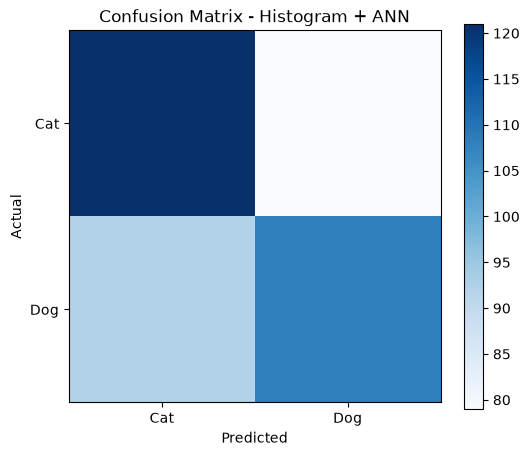


ANN - HOG
Accuracy: 0.73

Confusion Matrix:
[[148  52]
 [ 56 144]]

Classification Report:
              precision    recall  f1-score   support

         Cat       0.73      0.74      0.73       200
         Dog       0.73      0.72      0.73       200

    accuracy                           0.73       400
   macro avg       0.73      0.73      0.73       400
weighted avg       0.73      0.73      0.73       400



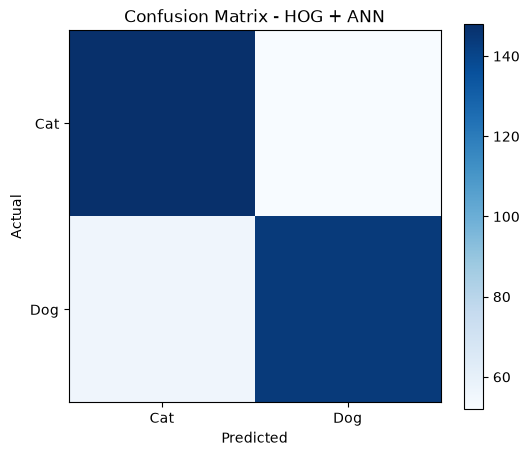

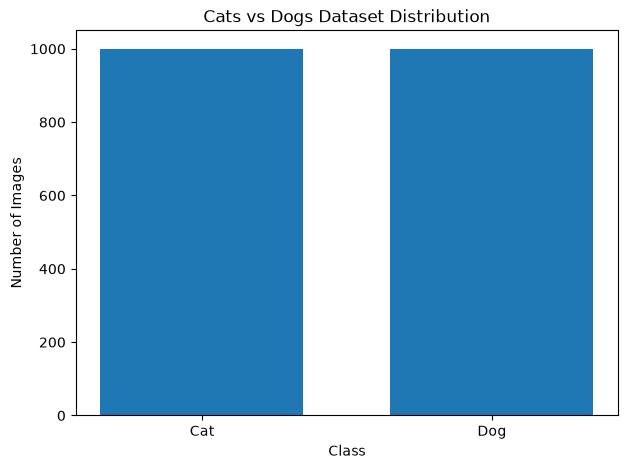


FINAL COMPARISON
Histogram + Statistics + Edges Accuracy: 0.5725
HOG Accuracy: 0.73
Histogram Features: 107
HOG Features: 8100


In [10]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# =========================================================
# 1 - Dataset Path
# =========================================================

dataset_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\dogs-vs-cats\train\train"


# =========================================================
# 2 - قراءة أسماء الصور
# =========================================================

images = [
    image for image in os.listdir(dataset_path)
    if image.lower().endswith((".jpg", ".jpeg", ".png"))
]


# =========================================================
# 3 - فصل Cats و Dogs
# =========================================================

cat_images = [
    image for image in images
    if image.lower().startswith("cat.")
]

dog_images = [
    image for image in images
    if image.lower().startswith("dog.")
]


print("Total Cats:", len(cat_images))
print("Total Dogs:", len(dog_images))


# =========================================================
# 4 - أخذ 2000 صورة عشوائية
# =========================================================

random.seed(42)

cat_images = random.sample(cat_images, 1000)

dog_images = random.sample(dog_images, 1000)


print("\nSelected Cats:", len(cat_images))
print("Selected Dogs:", len(dog_images))
print("Total Selected:", len(cat_images) + len(dog_images))


# =========================================================
# 5 - Histogram Features
# =========================================================

def extract_histogram(image):

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    image = cv2.resize(
        image,
        (128, 128)
    )

    features = []

    for channel in range(3):

        hist = cv2.calcHist(
            [image],
            [channel],
            None,
            [32],
            [0, 256]
        )

        hist = cv2.normalize(
            hist,
            hist
        )

        features.extend(
            hist.flatten()
        )

    return np.array(features)


# =========================================================
# 6 - Statistical Features
# =========================================================

def extract_statistics(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    features = [
        gray.mean(),
        gray.std(),
        gray.min(),
        gray.max(),
        np.median(gray),
        np.percentile(gray, 25),
        np.percentile(gray, 75)
    ]

    return np.array(features)


# =========================================================
# 7 - Edge Features
# =========================================================

def extract_edges(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    gray = cv2.resize(
        gray,
        (128, 128)
    )

    # Canny
    edges = cv2.Canny(
        gray,
        100,
        200
    )

    # Edge Density
    edge_density = np.mean(
        edges > 0
    )

    # Horizontal Edges
    horizontal_kernel = np.array([
        [-1, -1, -1],
        [ 2,  2,  2],
        [-1, -1, -1]
    ])

    horizontal = cv2.filter2D(
        gray,
        -1,
        horizontal_kernel
    )

    horizontal_density = np.mean(
        np.abs(horizontal) > 50
    )

    # Vertical Edges
    vertical_kernel = np.array([
        [-1,  2, -1],
        [-1,  2, -1],
        [-1,  2, -1]
    ])

    vertical = cv2.filter2D(
        gray,
        -1,
        vertical_kernel
    )

    vertical_density = np.mean(
        np.abs(vertical) > 50
    )

    # Contours
    contours, _ = cv2.findContours(
        edges,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    number_of_contours = len(contours)

    return np.array([
        edge_density,
        horizontal_density,
        vertical_density,
        number_of_contours
    ])


# =========================================================
# 8 - HOG Features
# =========================================================

def extract_hog(image):

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )

    gray = cv2.resize(
        gray,
        (128, 128)
    )

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
    )

    return features


# =========================================================
# 9 - استخراج Features
# =========================================================

X_hist = []
X_hog = []
y = []


print("\nExtracting Features...")


# =========================================================
# 10 - Cats
# =========================================================

for image_name in cat_images:

    image_path = os.path.join(
        dataset_path,
        image_name
    )

    image = cv2.imread(
        image_path
    )

    if image is None:
        continue

    # Histogram
    hist_features = extract_histogram(
        image
    )

    # Statistics
    stat_features = extract_statistics(
        image
    )

    # Edges
    edge_features = extract_edges(
        image
    )

    # دمج الخصائص
    combined_features = np.concatenate([
        hist_features,
        stat_features,
        edge_features
    ])

    X_hist.append(
        combined_features
    )

    # HOG
    hog_features = extract_hog(
        image
    )

    X_hog.append(
        hog_features
    )

    # Cat = 0
    y.append(0)


# =========================================================
# 11 - Dogs
# =========================================================

for image_name in dog_images:

    image_path = os.path.join(
        dataset_path,
        image_name
    )

    image = cv2.imread(
        image_path
    )

    if image is None:
        continue

    # Histogram
    hist_features = extract_histogram(
        image
    )

    # Statistics
    stat_features = extract_statistics(
        image
    )

    # Edges
    edge_features = extract_edges(
        image
    )

    # دمج الخصائص
    combined_features = np.concatenate([
        hist_features,
        stat_features,
        edge_features
    ])

    X_hist.append(
        combined_features
    )

    # HOG
    hog_features = extract_hog(
        image
    )

    X_hog.append(
        hog_features
    )

    # Dog = 1
    y.append(1)


# =========================================================
# 12 - تحويل إلى NumPy
# =========================================================

X_hist = np.array(X_hist)

X_hog = np.array(X_hog)

y = np.array(y)


print("\n================================")
print("FEATURE INFORMATION")
print("================================")

print(
    "Histogram + Statistics + Edges:"
)

print(
    "Shape:",
    X_hist.shape
)

print(
    "Features per Image:",
    X_hist.shape[1]
)


print("\nHOG:")

print(
    "Shape:",
    X_hog.shape
)

print(
    "Features per Image:",
    X_hog.shape[1]
)


print("\nLabels:")

print(
    "Shape:",
    y.shape
)


# =========================================================
# 13 - تقسيم البيانات
# =========================================================

X_hist_train, X_hist_test, y_train, y_test = train_test_split(
    X_hist,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


X_hog_train, X_hog_test, _, _ = train_test_split(
    X_hog,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n================================")
print("DATASET SPLIT")
print("================================")

print(
    "Training:",
    len(X_hist_train)
)

print(
    "Testing:",
    len(X_hist_test)
)


# =========================================================
# 14 - StandardScaler
# =========================================================

scaler_hist = StandardScaler()

X_hist_train = scaler_hist.fit_transform(
    X_hist_train
)

X_hist_test = scaler_hist.transform(
    X_hist_test
)


# =========================================================
# 15 - ANN
# Histogram + Statistics + Edges
# =========================================================

print("\n================================")
print("ANN - HISTOGRAM + STATISTICS + EDGES")
print("================================")


clf_hist = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=100,
    random_state=42
)


clf_hist.fit(
    X_hist_train,
    y_train
)


# Prediction
y_pred_hist = clf_hist.predict(
    X_hist_test
)


# Accuracy
accuracy_hist = accuracy_score(
    y_test,
    y_pred_hist
)


print(
    "Accuracy:",
    accuracy_hist
)


# =========================================================
# 16 - Confusion Matrix
# =========================================================

cm_hist = confusion_matrix(
    y_test,
    y_pred_hist
)


print("\nConfusion Matrix:")

print(
    cm_hist
)


# =========================================================
# 17 - Classification Report
# =========================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_hist,
        target_names=[
            "Cat",
            "Dog"
        ]
    )
)


# =========================================================
# 18 - عرض Confusion Matrix
# =========================================================

plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    cm_hist,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - Histogram + ANN"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    ["Cat", "Dog"]
)

plt.yticks(
    [0, 1],
    ["Cat", "Dog"]
)

plt.colorbar()

plt.show()


# =========================================================
# 19 - StandardScaler للـ HOG
# =========================================================

scaler_hog = StandardScaler()

X_hog_train = scaler_hog.fit_transform(
    X_hog_train
)

X_hog_test = scaler_hog.transform(
    X_hog_test
)


# =========================================================
# 20 - ANN + HOG
# =========================================================

print("\n================================")
print("ANN - HOG")
print("================================")


clf_hog = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=100,
    random_state=42
)


clf_hog.fit(
    X_hog_train,
    y_train
)


# Prediction
y_pred_hog = clf_hog.predict(
    X_hog_test
)


# Accuracy
accuracy_hog = accuracy_score(
    y_test,
    y_pred_hog
)


print(
    "Accuracy:",
    accuracy_hog
)


# =========================================================
# 21 - Confusion Matrix HOG
# =========================================================

cm_hog = confusion_matrix(
    y_test,
    y_pred_hog
)


print("\nConfusion Matrix:")

print(
    cm_hog
)


# =========================================================
# 22 - Classification Report HOG
# =========================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred_hog,
        target_names=[
            "Cat",
            "Dog"
        ]
    )
)


# =========================================================
# 23 - عرض Confusion Matrix HOG
# =========================================================

plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    cm_hog,
    cmap="Blues"
)

plt.title(
    "Confusion Matrix - HOG + ANN"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    ["Cat", "Dog"]
)

plt.yticks(
    [0, 1],
    ["Cat", "Dog"]
)

plt.colorbar()

plt.show()


# =========================================================
# 24 - Histogram Cats vs Dogs
# =========================================================

plt.figure(
    figsize=(7, 5)
)

plt.hist(
    y,
    bins=[-0.5, 0.5, 1.5],
    rwidth=0.7
)

plt.xticks(
    [0, 1],
    ["Cat", "Dog"]
)

plt.xlabel(
    "Class"
)

plt.ylabel(
    "Number of Images"
)

plt.title(
    "Cats vs Dogs Dataset Distribution"
)

plt.show()


# =========================================================
# 25 - المقارنة النهائية
# =========================================================

print("\n================================")
print("FINAL COMPARISON")
print("================================")

print(
    "Histogram + Statistics + Edges Accuracy:",
    accuracy_hist
)

print(
    "HOG Accuracy:",
    accuracy_hog
)

print(
    "Histogram Features:",
    X_hist.shape[1]
)

print(
    "HOG Features:",
    X_hog.shape[1]
)

عدد الصور: 2000
عدد Features: 8100
شكل X: (2000, 8100)
شكل y: (2000,)

X_train: (1600, 8100)
X_test : (400, 8100)
y_train: (1600,)
y_test : (400,)

Training ANN...

ANN + HOG
Accuracy: 0.7325

Classification Report:
              precision    recall  f1-score   support

         Cat       0.73      0.73      0.73       200
         Dog       0.73      0.73      0.73       200

    accuracy                           0.73       400
   macro avg       0.73      0.73      0.73       400
weighted avg       0.73      0.73      0.73       400


Confusion Matrix:
[[147  53]
 [ 54 146]]


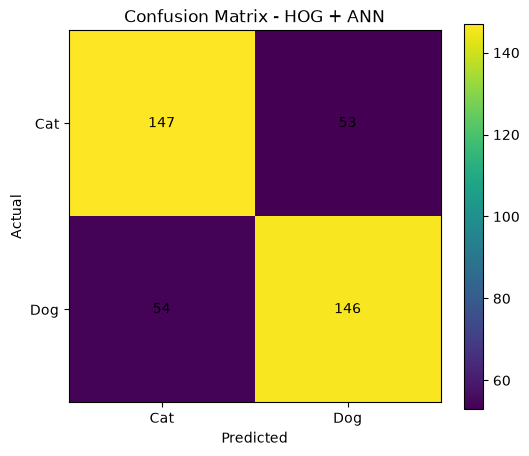


تم حفظ الموديل بنجاح.


In [1]:
import os
import cv2
import random
import numpy as np

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import joblib


# ==========================================
# 1 - مسار Dataset
# ==========================================

dataset_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\dogs-vs-cats\train\train"


# ==========================================
# 2 - قراءة أسماء الصور
# ==========================================

images = [
    image for image in os.listdir(dataset_path)
    if image.lower().endswith((".jpg", ".jpeg", ".png"))
]

cat_images = [
    image for image in images
    if image.lower().startswith("cat.")
]

dog_images = [
    image for image in images
    if image.lower().startswith("dog.")
]


# ==========================================
# 3 - أخذ 1000 Cat + 1000 Dog
# ==========================================

random.seed(42)

cat_images = random.sample(cat_images, 1000)
dog_images = random.sample(dog_images, 1000)


selected_images = cat_images + dog_images


# ==========================================
# 4 - استخراج HOG
# ==========================================

X = []
y = []


for image_name in selected_images:

    image_path = os.path.join(dataset_path, image_name)

    image = cv2.imread(image_path)

    if image is None:
        continue

    # Resize
    image = cv2.resize(image, (128, 128))

    # Gray
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # HOG
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
    )

    X.append(features)

    # Cat = 0
    # Dog = 1
    if image_name.startswith("cat."):
        y.append(0)
    else:
        y.append(1)


# تحويل إلى NumPy
X = np.array(X)
y = np.array(y)


print("عدد الصور:", len(X))
print("عدد Features:", X.shape[1])
print("شكل X:", X.shape)
print("شكل y:", y.shape)


# ==========================================
# 5 - تقسيم البيانات
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nX_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


# ==========================================
# 6 - StandardScaler
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# ==========================================
# 7 - ANN
# ==========================================

model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=100,
    random_state=42
)


print("\nTraining ANN...")

model.fit(X_train, y_train)


# ==========================================
# 8 - Prediction
# ==========================================

y_pred = model.predict(X_test)


# ==========================================
# 9 - Accuracy
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("ANN + HOG")
print("==============================")

print("Accuracy:", accuracy)


# ==========================================
# 10 - Classification Report
# ==========================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Cat", "Dog"]
    )
)


# ==========================================
# 11 - Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - HOG + ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Cat", "Dog"])
plt.yticks([0, 1], ["Cat", "Dog"])

plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()


# ==========================================
# 12 - حفظ الموديل والـ Scaler
# ==========================================

joblib.dump(model, "hog_ann_model.pkl")

joblib.dump(scaler, "hog_scaler.pkl")


print("\nتم حفظ الموديل بنجاح.")

عدد الصور التي سيتم اختبارها: 10
--------------------------------------
Image      : 8177.jpg
Prediction : CAT
Confidence : 99.81 %


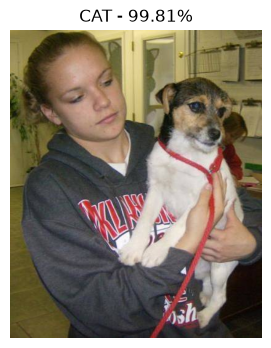

--------------------------------------
Image      : 1164.jpg
Prediction : CAT
Confidence : 99.98 %


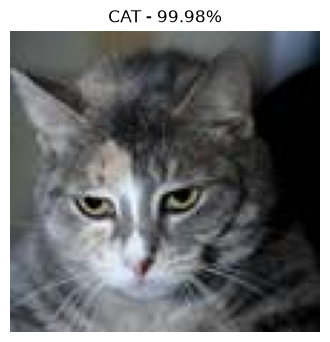

--------------------------------------
Image      : 10366.jpg
Prediction : DOG
Confidence : 99.93 %


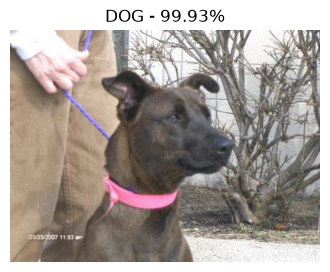

--------------------------------------
Image      : 9683.jpg
Prediction : CAT
Confidence : 99.96 %


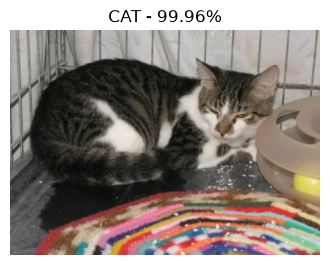

--------------------------------------
Image      : 2803.jpg
Prediction : CAT
Confidence : 96.09 %


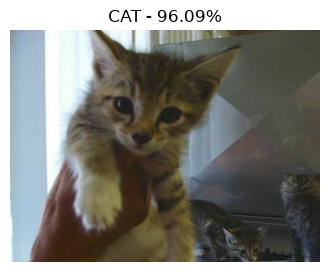

--------------------------------------
Image      : 2359.jpg
Prediction : DOG
Confidence : 99.23 %


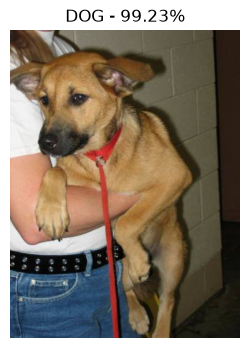

--------------------------------------
Image      : 2039.jpg
Prediction : DOG
Confidence : 99.51 %


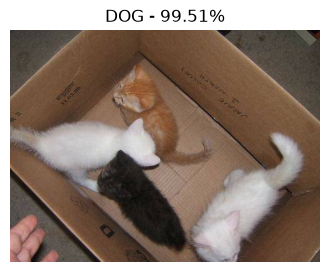

--------------------------------------
Image      : 12055.jpg
Prediction : DOG
Confidence : 99.99 %


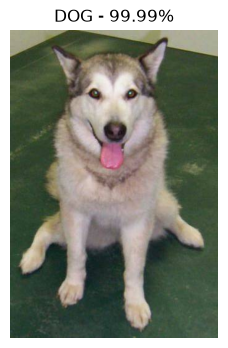

--------------------------------------
Image      : 9608.jpg
Prediction : DOG
Confidence : 90.11 %


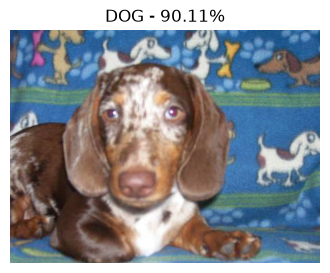

--------------------------------------
Image      : 11509.jpg
Prediction : CAT
Confidence : 95.71 %


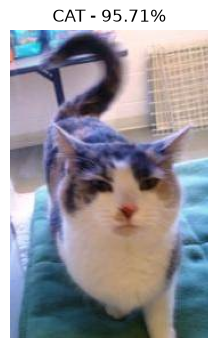

In [3]:
import os
import cv2
import joblib
import random

from skimage.feature import hog

import matplotlib.pyplot as plt


# ==========================================
# 1 - مسار مجموعة الصور
# ==========================================

test_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\dogs-vs-cats\test1\test1"


# ==========================================
# 2 - تحميل الموديل والـ Scaler
# ==========================================

model = joblib.load("hog_ann_model.pkl")

scaler = joblib.load("hog_scaler.pkl")


# ==========================================
# 3 - قراءة الصور
# ==========================================

images = [
    image for image in os.listdir(test_path)
    if image.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
]


# ==========================================
# 4 - اختيار 10 صور عشوائية
# ==========================================

random.seed(42)

if len(images) >= 10:
    images = random.sample(images, 10)
else:
    print("عدد الصور أقل من 10")
    images = images


print("عدد الصور التي سيتم اختبارها:", len(images))


# ==========================================
# 5 - اختبار الصور
# ==========================================

for image_name in images:

    image_path = os.path.join(
        test_path,
        image_name
    )

    # قراءة الصورة
    image = cv2.imread(image_path)

    if image is None:
        continue


    # ======================================
    # Resize
    # ======================================

    image_resized = cv2.resize(
        image,
        (128, 128)
    )


    # ======================================
    # Grayscale
    # ======================================

    gray = cv2.cvtColor(
        image_resized,
        cv2.COLOR_BGR2GRAY
    )


    # ======================================
    # HOG
    # ======================================

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
    )


    # ======================================
    # تحويل إلى 2D
    # ======================================

    features = features.reshape(1, -1)


    # ======================================
    # Scaling
    # ======================================

    features = scaler.transform(features)


    # ======================================
    # Prediction
    # ======================================

    prediction = model.predict(features)[0]


    # ======================================
    # Confidence
    # ======================================

    probabilities = model.predict_proba(features)[0]

    confidence = probabilities[prediction] * 100


    # ======================================
    # اسم النتيجة
    # ======================================

    if prediction == 0:
        result = "CAT"
    else:
        result = "DOG"


    # ======================================
    # طباعة النتيجة
    # ======================================

    print("--------------------------------------")
    print("Image      :", image_name)
    print("Prediction :", result)
    print("Confidence :", round(confidence, 2), "%")


    # ======================================
    # عرض الصورة
    # ======================================

    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(4, 4))

    plt.imshow(image_rgb)

    plt.title(
        result + " - " +
        str(round(confidence, 2)) + "%"
    )

    plt.axis("off")

    plt.show()

عدد الصور: 2000
HOG Features: 8100
HOG + Hu Features: 8107

Training HOG only...

Training HOG + Hu Moments...

          COMPARISON

HOG فقط
Features : 8100
Accuracy : 73.25 %
Training Time : 5.87 seconds

HOG + Hu Moments
Features : 8107
Accuracy : 74.0 %
Training Time : 5.09 seconds


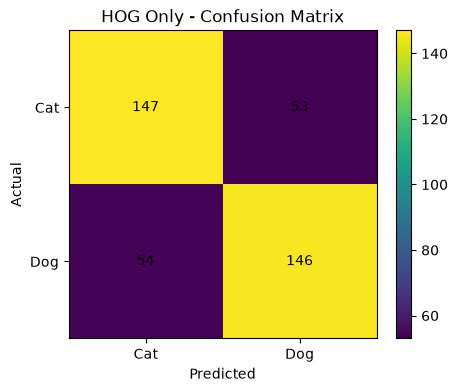

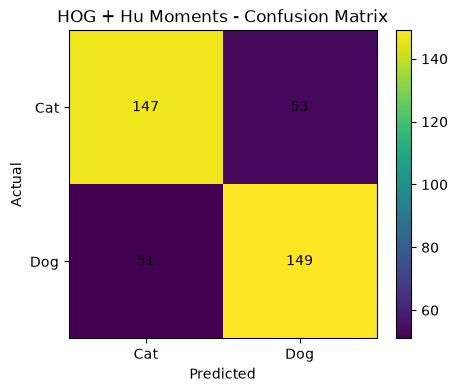


HOG Classification Report
              precision    recall  f1-score   support

         Cat       0.73      0.73      0.73       200
         Dog       0.73      0.73      0.73       200

    accuracy                           0.73       400
   macro avg       0.73      0.73      0.73       400
weighted avg       0.73      0.73      0.73       400


HOG + Hu Classification Report
              precision    recall  f1-score   support

         Cat       0.74      0.73      0.74       200
         Dog       0.74      0.74      0.74       200

    accuracy                           0.74       400
   macro avg       0.74      0.74      0.74       400
weighted avg       0.74      0.74      0.74       400



In [4]:
import os
import cv2
import random
import time
import numpy as np

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt


# ==========================================
# 1 - Dataset
# ==========================================

dataset_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\dogs-vs-cats\train\train"


# ==========================================
# 2 - قراءة الصور
# ==========================================

images = [
    image for image in os.listdir(dataset_path)
    if image.lower().endswith((".jpg", ".jpeg", ".png"))
]

cat_images = [
    image for image in images
    if image.lower().startswith("cat.")
]

dog_images = [
    image for image in images
    if image.lower().startswith("dog.")
]


# ==========================================
# 3 - أخذ 1000 Cat + 1000 Dog
# ==========================================

random.seed(42)

cat_images = random.sample(cat_images, 1000)
dog_images = random.sample(dog_images, 1000)

selected_images = cat_images + dog_images


# ==========================================
# 4 - استخراج HOG و Hu Moments
# ==========================================

X_hog = []
X_hog_hu = []
y = []


for image_name in selected_images:

    image_path = os.path.join(
        dataset_path,
        image_name
    )

    image = cv2.imread(image_path)

    if image is None:
        continue


    # ======================================
    # Resize
    # ======================================

    image = cv2.resize(
        image,
        (128, 128)
    )


    # ======================================
    # Grayscale
    # ======================================

    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # ======================================
    # HOG
    # ======================================

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
    )


    # ======================================
    # Threshold
    # ======================================

    _, binary = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )


    # ======================================
    # Contours
    # ======================================

    contours, _ = cv2.findContours(
        binary,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )


    # ======================================
    # Hu Moments
    # ======================================

    hu_features = np.zeros(7)


    if len(contours) > 0:

        # أخذ أكبر contour
        contour = max(
            contours,
            key=cv2.contourArea
        )

        moments = cv2.moments(contour)

        hu = cv2.HuMoments(moments)

        hu = hu.flatten()


        # Log Transform
        for i in range(7):

            if hu[i] != 0:

                hu_features[i] = (
                    -np.sign(hu[i]) *
                    np.log10(abs(hu[i]))
                )


    # ======================================
    # HOG فقط
    # ======================================

    X_hog.append(hog_features)


    # ======================================
    # HOG + Hu Moments
    # ======================================

    combined_features = np.concatenate(
        [hog_features, hu_features]
    )

    X_hog_hu.append(combined_features)


    # ======================================
    # Label
    # ======================================

    if image_name.startswith("cat."):
        y.append(0)
    else:
        y.append(1)


# ==========================================
# 5 - NumPy
# ==========================================

X_hog = np.array(X_hog)

X_hog_hu = np.array(X_hog_hu)

y = np.array(y)


print("عدد الصور:", len(y))

print("HOG Features:",
      X_hog.shape[1])

print("HOG + Hu Features:",
      X_hog_hu.shape[1])


# ==========================================
# 6 - نفس Train/Test
# ==========================================

indices = np.arange(len(y))

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ==========================================
# 7 - HOG فقط
# ==========================================

X_train_hog = X_hog[train_idx]
X_test_hog = X_hog[test_idx]

y_train = y[train_idx]
y_test = y[test_idx]


# Scaling
scaler_hog = StandardScaler()

X_train_hog = scaler_hog.fit_transform(
    X_train_hog
)

X_test_hog = scaler_hog.transform(
    X_test_hog
)


# ==========================================
# 8 - ANN + HOG
# ==========================================

print("\nTraining HOG only...")

start = time.time()

model_hog = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=100,
    random_state=42
)

model_hog.fit(
    X_train_hog,
    y_train
)

hog_time = time.time() - start


# Prediction
y_pred_hog = model_hog.predict(
    X_test_hog
)


# Accuracy
accuracy_hog = accuracy_score(
    y_test,
    y_pred_hog
)


# ==========================================
# 9 - HOG + Hu Moments
# ==========================================

X_train_hu = X_hog_hu[train_idx]
X_test_hu = X_hog_hu[test_idx]


# Scaling
scaler_hu = StandardScaler()

X_train_hu = scaler_hu.fit_transform(
    X_train_hu
)

X_test_hu = scaler_hu.transform(
    X_test_hu
)


# ==========================================
# 10 - ANN + HOG + Hu
# ==========================================

print("\nTraining HOG + Hu Moments...")

start = time.time()

model_hu = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=100,
    random_state=42
)

model_hu.fit(
    X_train_hu,
    y_train
)

hu_time = time.time() - start


# Prediction
y_pred_hu = model_hu.predict(
    X_test_hu
)


# Accuracy
accuracy_hu = accuracy_score(
    y_test,
    y_pred_hu
)


# ==========================================
# 11 - النتائج
# ==========================================

print("\n======================================")
print("          COMPARISON")
print("======================================")

print("\nHOG فقط")
print("Features :", X_hog.shape[1])
print("Accuracy :", round(accuracy_hog * 100, 2), "%")
print("Training Time :", round(hog_time, 2), "seconds")


print("\nHOG + Hu Moments")
print("Features :", X_hog_hu.shape[1])
print("Accuracy :", round(accuracy_hu * 100, 2), "%")
print("Training Time :", round(hu_time, 2), "seconds")


# ==========================================
# 12 - Confusion Matrix HOG
# ==========================================

cm_hog = confusion_matrix(
    y_test,
    y_pred_hog
)

plt.figure(figsize=(5, 4))

plt.imshow(cm_hog)

plt.title("HOG Only - Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Cat", "Dog"]
)

plt.yticks(
    [0, 1],
    ["Cat", "Dog"]
)

plt.colorbar()

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm_hog[i, j],
            ha="center",
            va="center"
        )

plt.show()


# ==========================================
# 13 - Confusion Matrix HOG + Hu
# ==========================================

cm_hu = confusion_matrix(
    y_test,
    y_pred_hu
)

plt.figure(figsize=(5, 4))

plt.imshow(cm_hu)

plt.title("HOG + Hu Moments - Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Cat", "Dog"]
)

plt.yticks(
    [0, 1],
    ["Cat", "Dog"]
)

plt.colorbar()

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm_hu[i, j],
            ha="center",
            va="center"
        )

plt.show()


# ==========================================
# 14 - Classification Reports
# ==========================================

print("\n======================================")
print("HOG Classification Report")
print("======================================")

print(
    classification_report(
        y_test,
        y_pred_hog,
        target_names=["Cat", "Dog"]
    )
)


print("\n======================================")
print("HOG + Hu Classification Report")
print("======================================")

print(
    classification_report(
        y_test,
        y_pred_hu,
        target_names=["Cat", "Dog"]
    )
)

عدد صور Cat المتاحة: 12500
عدد صور Dog المتاحة: 12500

عدد الصور المستخدمة: 2000

Extracting HOG Features...

HOG INFORMATION
Number of Images : 2000
Number of Features : 1764
X Shape : (2000, 1764)
y Shape : (2000,)

DATA SPLIT
X_train : (1600, 1764)
X_test  : (400, 1764)
y_train : (1600,)
y_test  : (400,)

TRAINING ANN
Training completed.

MODEL RESULTS
Accuracy: 74.0 %

Classification Report
              precision    recall  f1-score   support

         Cat       0.76      0.70      0.73       200
         Dog       0.72      0.78      0.75       200

    accuracy                           0.74       400
   macro avg       0.74      0.74      0.74       400
weighted avg       0.74      0.74      0.74       400


Confusion Matrix:
[[141  59]
 [ 45 155]]


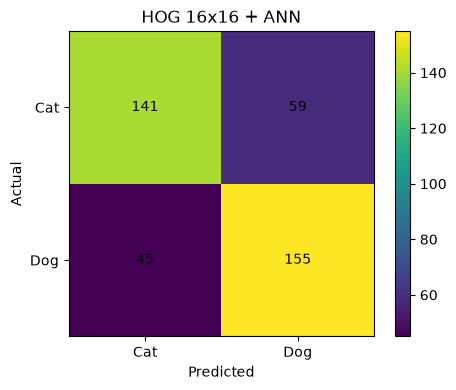


MODEL SAVED
hog16_ann_model.pkl
hog16_scaler.pkl

TEST DATASET
Available Test Images: 12500
Images Used for Testing: 10

10 TEST IMAGES RESULTS
--------------------------------------
Image      : 8177.jpg
Prediction : DOG
Confidence : 95.96 %
--------------------------------------
Image      : 1164.jpg
Prediction : CAT
Confidence : 100.0 %
--------------------------------------
Image      : 10366.jpg
Prediction : DOG
Confidence : 99.99 %
--------------------------------------
Image      : 9683.jpg
Prediction : CAT
Confidence : 94.39 %
--------------------------------------
Image      : 2803.jpg
Prediction : CAT
Confidence : 96.3 %
--------------------------------------
Image      : 2359.jpg
Prediction : DOG
Confidence : 93.94 %
--------------------------------------
Image      : 2039.jpg
Prediction : CAT
Confidence : 60.16 %
--------------------------------------
Image      : 12055.jpg
Prediction : DOG
Confidence : 99.95 %
--------------------------------------
Image      : 9608.jpg
P

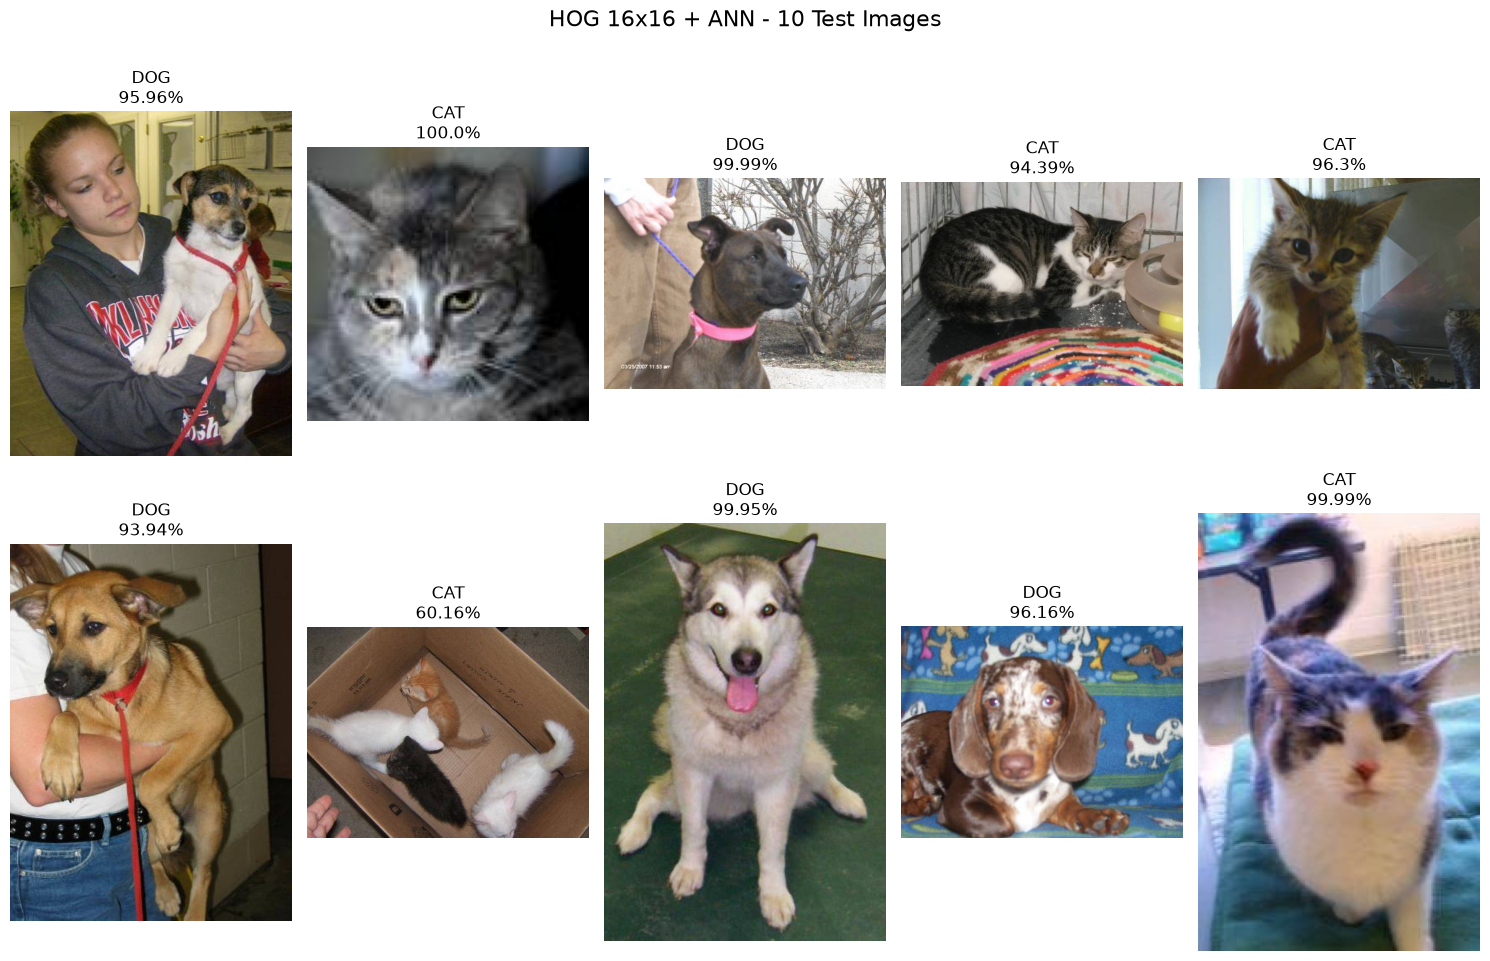


DONE
Training + Saving + Testing completed.


In [10]:
import os
import cv2
import random
import joblib
import numpy as np
import matplotlib.pyplot as plt

from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ==========================================================
# 1 - مسارات البيانات
# ==========================================================

dataset_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\dogs-vs-cats\train\train"

test_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\dogs-vs-cats\test1\test1"


# ==========================================================
# 2 - قراءة أسماء صور Dataset
# ==========================================================

images = [
    image for image in os.listdir(dataset_path)
    if image.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
]


# فصل Cat و Dog

cat_images = [
    image for image in images
    if image.lower().startswith("cat.")
]

dog_images = [
    image for image in images
    if image.lower().startswith("dog.")
]


print("عدد صور Cat المتاحة:", len(cat_images))
print("عدد صور Dog المتاحة:", len(dog_images))


# ==========================================================
# 3 - اختيار 1000 Cat + 1000 Dog
# ==========================================================

random.seed(42)

cat_images = random.sample(
    cat_images,
    1000
)

dog_images = random.sample(
    dog_images,
    1000
)


selected_images = cat_images + dog_images


print("\nعدد الصور المستخدمة:", len(selected_images))


# ==========================================================
# 4 - استخراج HOG 16x16
# ==========================================================

X = []
y = []


print("\nExtracting HOG Features...")


for image_name in selected_images:

    image_path = os.path.join(
        dataset_path,
        image_name
    )


    # قراءة الصورة
    image = cv2.imread(image_path)


    if image is None:
        continue


    # Resize
    image = cv2.resize(
        image,
        (128, 128)
    )


    # Grayscale
    gray = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2GRAY
    )


    # ======================================================
    # HOG
    # ======================================================

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2)
    )


    # إضافة Features
    X.append(features)


    # ======================================================
    # Labels
    # Cat = 0
    # Dog = 1
    # ======================================================

    if image_name.lower().startswith("cat."):
        y.append(0)

    else:
        y.append(1)


# تحويل إلى NumPy

X = np.array(X)

y = np.array(y)


print("\n======================================")
print("HOG INFORMATION")
print("======================================")

print("Number of Images :", len(X))
print("Number of Features :", X.shape[1])
print("X Shape :", X.shape)
print("y Shape :", y.shape)


# ==========================================================
# 5 - تقسيم البيانات
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\n======================================")
print("DATA SPLIT")
print("======================================")

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)


# ==========================================================
# 6 - StandardScaler
# ==========================================================

scaler = StandardScaler()


X_train = scaler.fit_transform(
    X_train
)


X_test = scaler.transform(
    X_test
)


# ==========================================================
# 7 - ANN
# ==========================================================

print("\n======================================")
print("TRAINING ANN")
print("======================================")


model = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=100,
    random_state=42
)


model.fit(
    X_train,
    y_train
)


print("Training completed.")


# ==========================================================
# 8 - اختبار Test الداخلي
# ==========================================================

y_pred = model.predict(
    X_test
)


accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n======================================")
print("MODEL RESULTS")
print("======================================")

print(
    "Accuracy:",
    round(accuracy * 100, 2),
    "%"
)


# ==========================================================
# 9 - Classification Report
# ==========================================================

print("\n======================================")
print("Classification Report")
print("======================================")


print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Cat",
            "Dog"
        ]
    )
)


# ==========================================================
# 10 - Confusion Matrix
# ==========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)


print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(5, 4))

plt.imshow(cm)

plt.title(
    "HOG 16x16 + ANN"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.xticks(
    [0, 1],
    ["Cat", "Dog"]
)

plt.yticks(
    [0, 1],
    ["Cat", "Dog"]
)

plt.colorbar()


for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )


plt.tight_layout()

plt.show()


# ==========================================================
# 11 - حفظ Model و Scaler
# ==========================================================

joblib.dump(
    model,
    "hog16_ann_model.pkl"
)


joblib.dump(
    scaler,
    "hog16_scaler.pkl"
)


print("\n======================================")
print("MODEL SAVED")
print("======================================")

print("hog16_ann_model.pkl")
print("hog16_scaler.pkl")


# ==========================================================
# 12 - قراءة صور Test الجديدة
# ==========================================================

test_images = [
    image for image in os.listdir(test_path)
    if image.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
]


print("\n======================================")
print("TEST DATASET")
print("======================================")

print(
    "Available Test Images:",
    len(test_images)
)


# ==========================================================
# 13 - اختيار 10 صور عشوائية
# ==========================================================

random.seed(42)


if len(test_images) >= 10:

    selected_test_images = random.sample(
        test_images,
        10
    )

else:

    selected_test_images = test_images


print(
    "Images Used for Testing:",
    len(selected_test_images)
)


# ==========================================================
# 14 - اختبار 10 صور
# ==========================================================

results = []


for image_name in selected_test_images:


    image_path = os.path.join(
        test_path,
        image_name
    )


    # قراءة الصورة
    image = cv2.imread(
        image_path
    )


    if image is None:

        print(
            "Could not read:",
            image_name
        )

        continue


    # حفظ الصورة الأصلية للعرض
    display_image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )


    # ======================================================
    # Resize
    # ======================================================

    image_resized = cv2.resize(
        image,
        (128, 128)
    )


    # ======================================================
    # Grayscale
    # ======================================================

    gray = cv2.cvtColor(
        image_resized,
        cv2.COLOR_BGR2GRAY
    )


    # ======================================================
    # HOG 16x16
    # ======================================================

    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2)
    )


    # تحويل إلى صف واحد
    features = features.reshape(
        1,
        -1
    )


    # ======================================================
    # Scaling
    # ======================================================

    features = scaler.transform(
        features
    )


    # ======================================================
    # Prediction
    # ======================================================

    prediction = model.predict(
        features
    )[0]


    # ======================================================
    # Confidence
    # ======================================================

    probabilities = model.predict_proba(
        features
    )[0]


    confidence = (
        probabilities[prediction] * 100
    )


    # ======================================================
    # Class Name
    # ======================================================

    if prediction == 0:

        result = "CAT"

    else:

        result = "DOG"


    # حفظ النتيجة
    results.append(
        (
            image_name,
            result,
            confidence,
            display_image
        )
    )


# ==========================================================
# 15 - طباعة نتائج الـ10 صور
# ==========================================================

print("\n======================================")
print("10 TEST IMAGES RESULTS")
print("======================================")


for image_name, result, confidence, image in results:

    print("--------------------------------------")

    print(
        "Image      :",
        image_name
    )

    print(
        "Prediction :",
        result
    )

    print(
        "Confidence :",
        round(confidence, 2),
        "%"
    )


# ==========================================================
# 16 - عرض الصور العشر في Grid
# ==========================================================

if len(results) > 0:

    plt.figure(
        figsize=(15, 10)
    )


    for i, (
        image_name,
        result,
        confidence,
        image
    ) in enumerate(results):


        plt.subplot(
            2,
            5,
            i + 1
        )


        plt.imshow(
            image
        )


        plt.title(
            result +
            "\n" +
            str(round(confidence, 2)) +
            "%"
        )


        plt.axis(
            "off"
        )


    plt.suptitle(
        "HOG 16x16 + ANN - 10 Test Images",
        fontsize=16
    )


    plt.tight_layout()

    plt.show()


# ==========================================================
# 17 - نهاية البرنامج
# ==========================================================

print("\n======================================")
print("DONE")
print("======================================")

print(
    "Training + Saving + Testing completed."
)

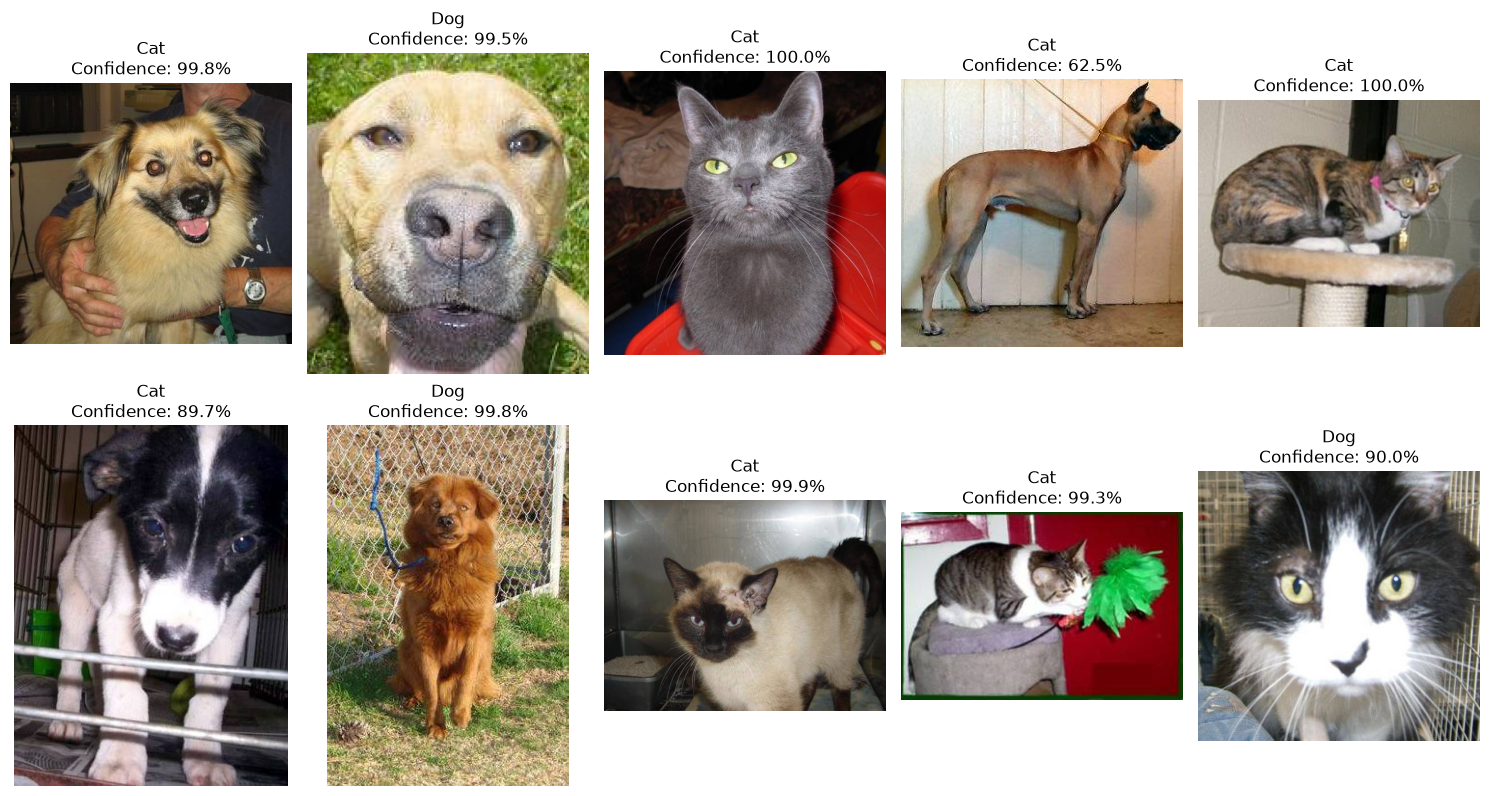

In [18]:
# ==========================================
# 8 - عرض 10 صور عشوائية
# ==========================================

random_results = random.sample(
    results,
    min(10, len(results))
)

plt.figure(figsize=(15, 8))

for i, (image_name, label, confidence) in enumerate(random_results):

    image_path = os.path.join(test_path, image_name)

    image = cv2.imread(image_path)

    # تحويل BGR إلى RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 5, i + 1)

    plt.imshow(image)

    plt.title(
        f"{label}\nConfidence: {confidence:.1f}%"
    )

    plt.axis("off")


plt.tight_layout()
plt.show()